In [6]:
from sionna.rt import load_scene, RadioMapSolver, Transmitter, PlanarArray
import numpy as np

# 1) Load scene

In [7]:
# empty scene
scene = load_scene()

# Set up antennas

In [8]:
scene.tx_array = PlanarArray(num_rows=8,
                             num_cols=8,
                             pattern="tr38901",
                             polarization="cross")

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             pattern="iso",
                             polarization="VH")

tx0 = Transmitter(name='tx0',
                  position=[0, 0, 20],  # BS at center of the scene at 20m height
                  orientation=[0, np.pi/9, 0],  # tilted downwards
                  power_dbm=44
                 )
scene.add(tx0)

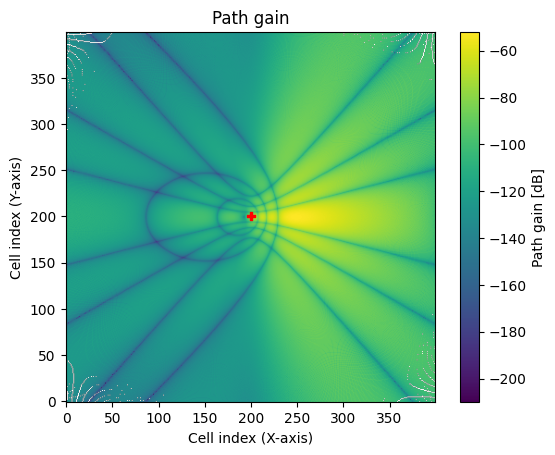

In [9]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical
rm.show(metric="path_gain");

# 3) Rotate the tx antenna around z-axis and recompute the path gain map

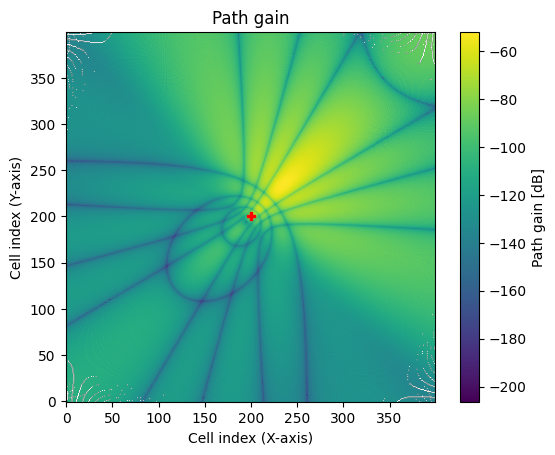

In [10]:
tx0.orientation[0] = np.pi/4
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map measurement plane, e.g., could be also vertical
rm.show(metric="path_gain");

# 4) Use a smaller antenna array at tx

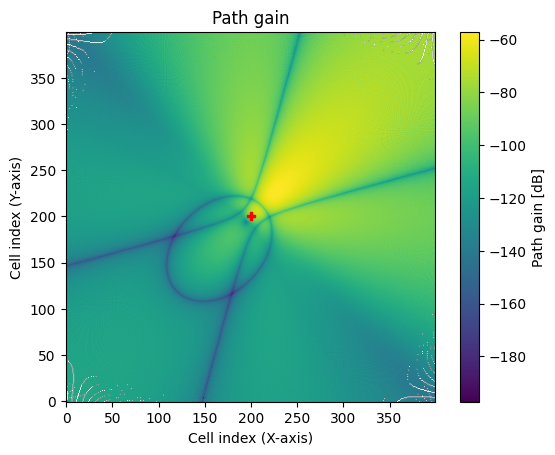

In [11]:
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             pattern="tr38901",
                             polarization="cross")

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray interactions in the scene
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical
rm.show(metric="path_gain");

## **Note:** 
We have a wider beam with 4x4 TX

# 5) Use an even smaller TX array

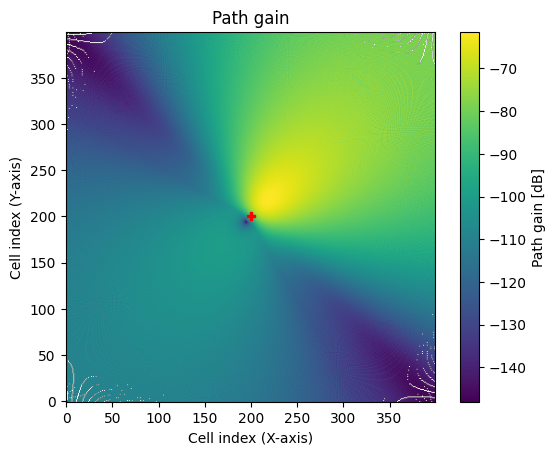

In [12]:
scene.tx_array = PlanarArray(num_rows=2,
                             num_cols=2,
                             pattern="tr38901",
                             polarization="cross")

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical
rm.show(metric="path_gain");

## **Notes:**
- Even wider beam with 2x2 TX!
- For radio map solver, receive antenna array params are assumed fixed and modifying them does not matter. See below from the Sionna RT technical report:
```
The receive antenna pattern is not applied here. Instead, the squared norm of the electric field is used. This is equivalent to assuming that a receiver positioned on the measurement plane uses a dual-polarized isotropic antenna, and that both components are combined non-coherently.
```

#  6) Observe which TX array dimension (horizontal vs. vertical) has more effect on beamwidth in the default measurement plane

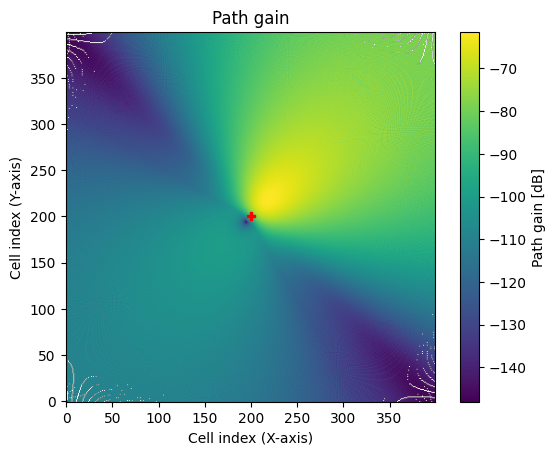

In [13]:
scene.tx_array = PlanarArray(num_rows=2,
                             num_cols=2,
                             pattern="tr38901",
                             polarization="cross")

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical
rm.show(metric="path_gain");

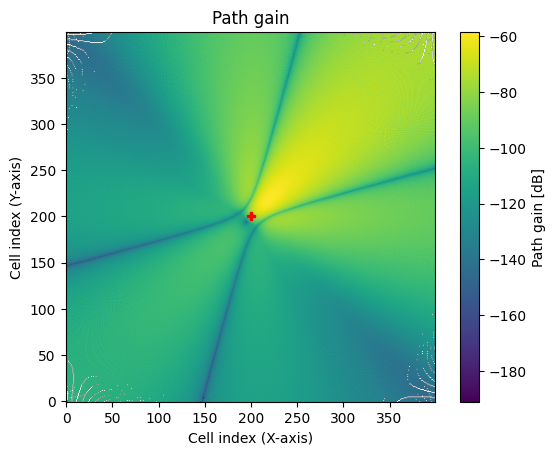

In [14]:
scene.tx_array = PlanarArray(num_rows=2,
                             num_cols=4,
                             pattern="tr38901",
                             polarization="cross")

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical
rm.show(metric="path_gain");

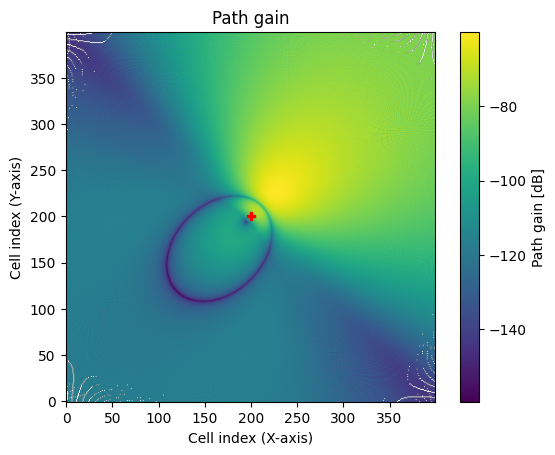

In [15]:
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=2,
                             pattern="tr38901",
                             polarization="cross")

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical
rm.show(metric="path_gain");

## **Notes:**
- Increasing the number of array elements placed parallel to the ground leads to narrawer beams in the default measurement plane.
- We cannot easily observe the increased spatial resolution in the orthogonal direction to the measurement plane.

# 7) Observe the effect of tx antenna tilt on the path gain

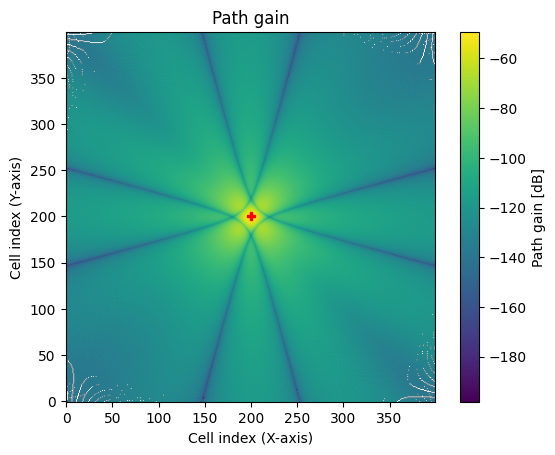

In [16]:
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             pattern="tr38901",
                             polarization="cross")

tx0.orientation[1] = np.pi/2  # pointing downwards

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

rm.show(metric="path_gain");

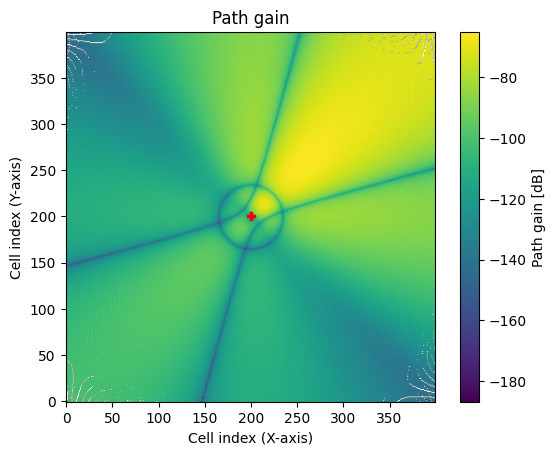

In [17]:
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             pattern="tr38901",
                             polarization="cross")

tx0.orientation[1] = 0  # no downward tilt

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

rm.show(metric="path_gain");

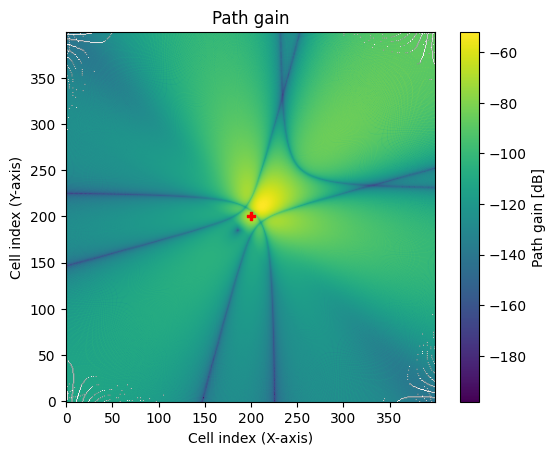

In [18]:
scene.tx_array = PlanarArray(num_rows=4,
                             num_cols=4,
                             pattern="tr38901",
                             polarization="cross")

tx0.orientation[1] = np.pi/4  # 45 degrees downward tilt

rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

rm.show(metric="path_gain");